# Nifty 100 Exploratory Data Analysis

In [80]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from analytics.db import run_query

In [81]:
def extract_percentage(value):
    if pd.isnull(value):
        return None
    
    try:
        return float(
            str(value)
            .split(":")[-1]
            .replace("%", "")
            .strip()
        )
    except:
        return None
    
def extract_period(value):
    if pd.isnull(value):
        return None
    
    try:
        return str(value).split(":")[0].strip()
    except:
        return None

In [82]:
tables = run_query("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema='public'
""")

tables

,table_name
0,dim_sector
1,dim_health_label
2,dim_company
3,fact_profit_loss
4,fact_balance_sheet
5,fact_cash_flow
6,fact_analysis
7,dim_year


In [83]:
dim_company = run_query("SELECT * FROM dim_company ORDER BY id ASC")
dim_company.head()

,id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.90
1,ADANIENSOL,https://m.economictimes.com/thumb/msid-1173715...,Adani Energy Solutions Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"AESL, part of the Adani portfolio, is a multid...",https://www.adanienergysolutions.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,175.0,9.0,8.59
2,ADANIENT,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Enterprises Ltd,https://in.tradingview.com/chart/?symbol=ADANIENT,Adani Enterprises Ltd is an Indian multination...,https://www.adanienterprises.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,1.0,363.0,11.6,13.64
3,ADANIGREEN,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Green Energy Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"Adani Green Energy Limited, incorporated in 20...",http://www.adanigreenenergy.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,67.0,96.5,14.70
4,ADANIPORTS,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Ports & Special Economic Zone Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Adani Ports & Special Economic Zone is in the ...,http://www.adaniports.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,2.0,265.0,12.9,18.10


In [89]:
fact_analysis = run_query("SELECT * FROM fact_analysis")
fact_analysis.head(20)

,id,company_id,compounded_sales_growth,compounded_profit_growth,stock_price_cagr,roe
0,1,HDFCBANK,10 Years: 21%,10 Years: 22%,10 Years: 15%,10 Years: 17%
1,10,SBILIFE,5 Years: 24%,5 Years: 6%,5 Years: 8%,5 Years 14%
2,11,SBILIFE,3 Years: 17%,3 Years: 9%,3 Years: 7%,3 Years: 13%
3,12,SBILIFE,TTM: 43%,TTM: 18%,1 Year: -2%,Last Year: 12%
4,13,TCS,10 Years: 11%,10 Years: 9%,10 Years: 14%,10 Years: 40%
5,14,TCS,5 Years: 10%,5 Years: 8%,5 Years: 16%,5 Years: 44%
6,15,TCS,3 Years: 14%,3 Years: 12%,3 Years: 8%,3 Years: 47%
7,16,TCS,TTM: 5%,TTM: 8%,1 Year: 16%,Last Year: 52%
8,17,WIPRO,10 Years: 8%,10 Years: 3%,10 Years: 12%,10 Years: 18%
9,18,WIPRO,5 Years: 9%,5 Years: 4%,5 Years: 20%,5 Years: 17%


In [90]:
fact_profit_loss = run_query ("SELECT * FROM fact_profit_loss")
fact_profit_loss.head()

,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout,fiscal_year,sorting_order,net_profit_margin_pct,expense_ratio_pct,interest_coverage
0,73,ABB,TTM,6066.0,4519.0,1547.0,26.0,265.0,11.0,72.0,1728.0,NaN,1285.0,605.0,NaN,NaN,9999,21.183647,74.497197,140.636364
1,97,ADANIENSOL,TTM,22099.0,15507.0,6592.0,NaN,-844.0,3183.0,1912.0,653.0,NaN,589.0,6.0,NaN,NaN,9999,2.665279,70.170596,2.071002
2,110,ADANIENT,TTM,102311.0,88418.0,13893.0,14.0,1489.0,4150.0,3541.0,7691.0,NaN,6086.0,49.0,NaN,NaN,9999,5.948529,86.420815,3.347711
3,119,ADANIGREEN,TTM,10782.0,2682.0,8100.0,75.0,891.0,4959.0,2323.0,1709.0,NaN,1928.0,9.0,0.0,NaN,9999,17.881655,24.874791,1.633394
4,132,ADANIPORTS,TTM,28443.0,11278.0,17165.0,60.0,1039.0,2591.0,4053.0,11560.0,NaN,9743.0,45.0,NaN,NaN,9999,34.254474,39.651232,6.624855


In [91]:
fact_free_cash_flow = run_query ("SELECT * FROM fact_cash_flow")
fact_free_cash_flow.head()


,id,company_id,year,operating_activity,investing_activity,financing_activity,net_cash_flow,fiscal_year,sorting_order,free_cash_flow
0,37,TCS,Mar 2013,11615.0,-6038.0,-5729.0,-152.0,2013,2013,5577.0
1,38,TCS,Mar 2014,14751.0,-9452.0,-5673.0,-374.0,2014,2014,5299.0
2,39,TCS,Mar 2015,19369.0,-1807.0,-17168.0,394.0,2015,2015,17562.0
3,40,TCS,Mar 2016,19109.0,-5010.0,-9666.0,4433.0,2016,2016,14099.0
4,41,TCS,Mar 2017,25223.0,-16895.0,-11026.0,-2698.0,2017,2017,8328.0


In [92]:
fact_balancesheet = run_query("SELECT * FROM fact_balance_sheet")
fact_balancesheet.head()

,id,company_id,year,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,fixed_assets,cwip,investments,other_asset,total_assets,fiscal_year,sorting_order,debt_to_equity,equity_ratio
0,136,ABB,Dec 2012,21.0,626.0,0.0,260.0,907.0,109.0,1.0,0.0,798.0,907.0,2012,2012,0.0,0.713341
1,137,ABB,Mar 2014,21.0,767.0,0.0,351.0,1139.0,98.0,1.0,0.0,1040.0,1139.0,2014,2014,0.0,0.691835
2,138,ABB,Mar 2015,21.0,916.0,0.0,436.0,1374.0,96.0,4.0,0.0,1274.0,1374.0,2015,2015,0.0,0.681951
3,139,ABB,Mar 2016,21.0,1174.0,0.0,421.0,1616.0,108.0,3.0,0.0,1505.0,1616.0,2016,2016,0.0,0.739480
4,140,ABB,Mar 2017,21.0,1366.0,0.0,679.0,2066.0,110.0,6.0,0.0,1950.0,2066.0,2017,2017,0.0,0.671346


# Data Cleaning & Feature Engineering

In [93]:
fact_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        20 non-null     int64 
 1   company_id                20 non-null     object
 2   compounded_sales_growth   20 non-null     object
 3   compounded_profit_growth  20 non-null     object
 4   stock_price_cagr          20 non-null     object
 5   roe                       20 non-null     object
dtypes: int64(1), object(5)
memory usage: 1.1+ KB


In [94]:
fact_analysis["sales_growth_pct"] = fact_analysis["compounded_sales_growth"].apply(extract_percentage)

fact_analysis["profit_growth_pct"] = fact_analysis["compounded_profit_growth"].apply(extract_percentage)

fact_analysis["stock_cagr_pct"] = fact_analysis["stock_price_cagr"].apply(extract_percentage)

fact_analysis["roe_pct"] = fact_analysis["roe"].apply(extract_percentage)
fact_analysis.head()

,id,company_id,compounded_sales_growth,compounded_profit_growth,stock_price_cagr,roe,sales_growth_pct,profit_growth_pct,stock_cagr_pct,roe_pct
0,1,HDFCBANK,10 Years: 21%,10 Years: 22%,10 Years: 15%,10 Years: 17%,21.0,22.0,15.0,17.0
1,10,SBILIFE,5 Years: 24%,5 Years: 6%,5 Years: 8%,5 Years 14%,24.0,6.0,8.0,NaN
2,11,SBILIFE,3 Years: 17%,3 Years: 9%,3 Years: 7%,3 Years: 13%,17.0,9.0,7.0,13.0
3,12,SBILIFE,TTM: 43%,TTM: 18%,1 Year: -2%,Last Year: 12%,43.0,18.0,-2.0,12.0
4,13,TCS,10 Years: 11%,10 Years: 9%,10 Years: 14%,10 Years: 40%,11.0,9.0,14.0,40.0


In [95]:
fact_analysis.describe()

,id,sales_growth_pct,profit_growth_pct,stock_cagr_pct,roe_pct
count,20.00000,20.000000,20.000000,20.000000,19.000000
mean,10.50000,16.350000,11.150000,12.900000,25.105263
std,5.91608,12.654415,7.942391,9.413876,12.587007
min,1.00000,-3.000000,0.000000,-2.000000,12.000000
25%,5.75000,8.750000,7.500000,8.000000,17.000000
50%,10.50000,13.000000,9.000000,12.500000,17.000000
75%,15.25000,22.250000,13.500000,16.000000,31.500000
max,20.00000,47.000000,27.000000,39.000000,52.000000


# Distribution Analysis

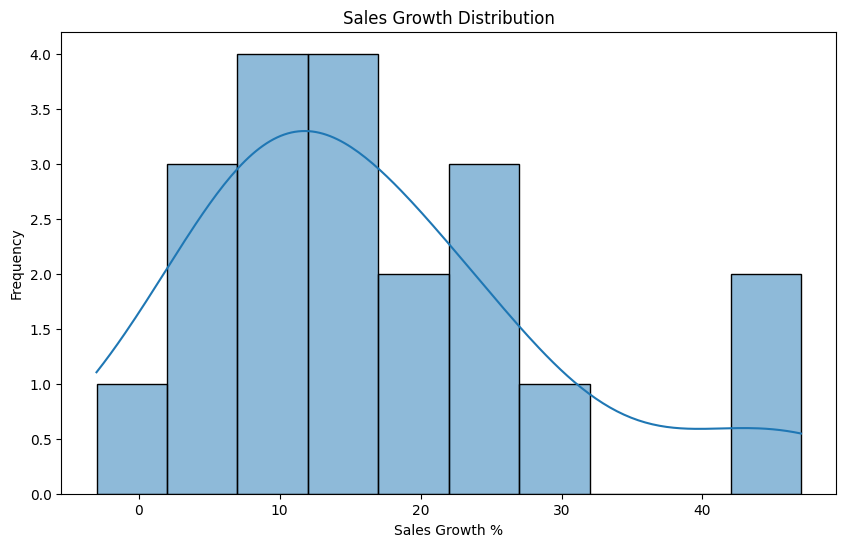

In [96]:
plt.figure(figsize=(10,6))

sns.histplot(
    fact_analysis["sales_growth_pct"],
    bins=10,
    kde=True
)

plt.title("Sales Growth Distribution")
plt.xlabel("Sales Growth %")
plt.ylabel("Frequency")

plt.show()

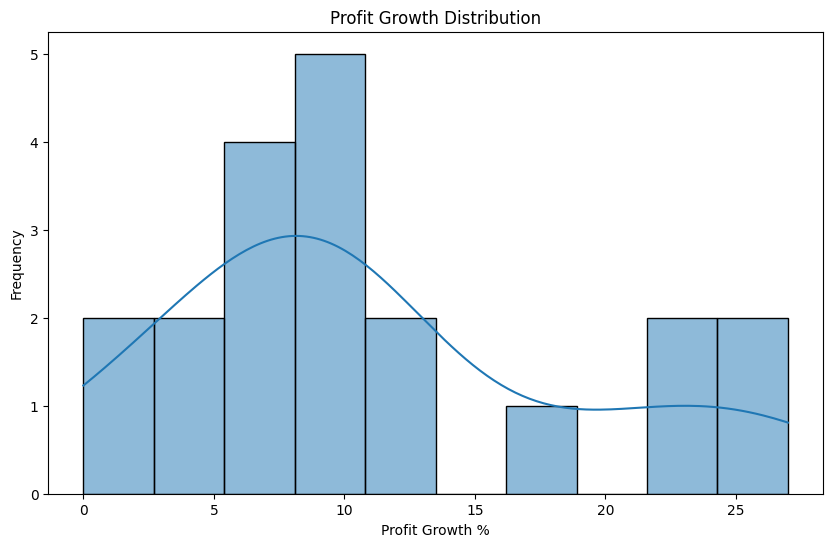

In [97]:
plt.figure(figsize=(10,6))

sns.histplot(
    fact_analysis["profit_growth_pct"],
    bins=10,
    kde=True
)

plt.title("Profit Growth Distribution")
plt.xlabel("Profit Growth %")
plt.ylabel("Frequency")

plt.show()

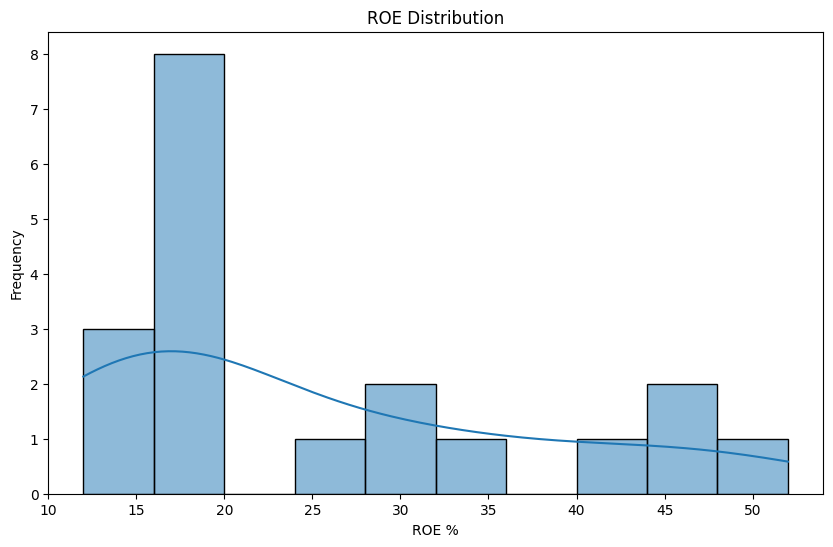

In [98]:

plt.figure(figsize=(10,6))

sns.histplot(
    fact_analysis["roe_pct"],
    bins=10,
    kde=True
)

plt.title("ROE Distribution")
plt.xlabel("ROE %")
plt.ylabel("Frequency")

plt.show()


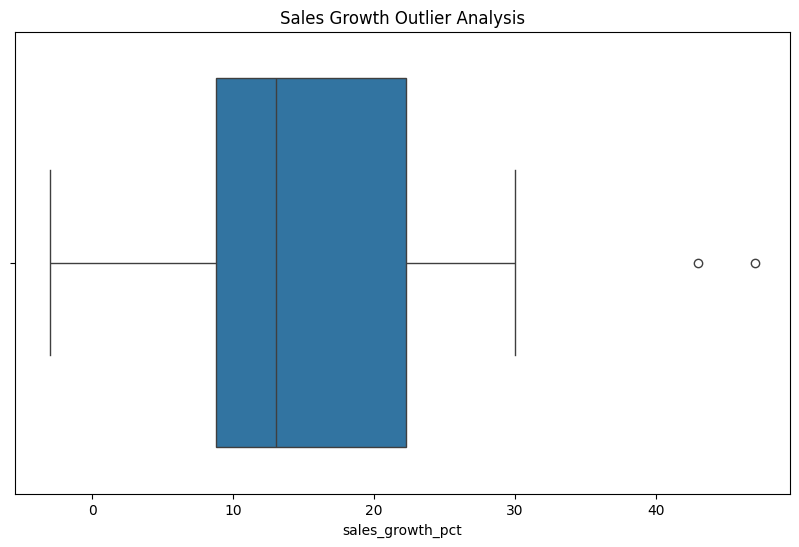

In [99]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=fact_analysis["sales_growth_pct"]
)

plt.title("Sales Growth Outlier Analysis")

plt.show()

# Top Performers


In [100]:
top_roe = fact_analysis.sort_values(
    by="roe_pct",
    ascending=False
).head(10)

top_roe

,id,company_id,compounded_sales_growth,compounded_profit_growth,stock_price_cagr,roe,sales_growth_pct,profit_growth_pct,stock_cagr_pct,roe_pct
7,16,TCS,TTM: 5%,TTM: 8%,1 Year: 16%,Last Year: 52%,5.0,8.0,16.0,52.0
6,15,TCS,3 Years: 14%,3 Years: 12%,3 Years: 8%,3 Years: 47%,14.0,12.0,8.0,47.0
5,14,TCS,5 Years: 10%,5 Years: 8%,5 Years: 16%,5 Years: 44%,10.0,8.0,16.0,44.0
4,13,TCS,10 Years: 11%,10 Years: 9%,10 Years: 14%,10 Years: 40%,11.0,9.0,14.0,40.0
18,8,INFY,TTM: 3%,TTM: 8%,1 Year: 27%,Last Year: 32%,3.0,8.0,27.0,32.0
17,7,INFY,3 Years: 5%,3 Years: 10%,3 Years: 4%,3 Years: 31%,5.0,10.0,4.0,31.0
16,6,INFY,5 Years: 13%,5 Years: 11%,5 Years: 22%,5 Years: 29%,13.0,11.0,22.0,29.0
15,5,INFY,10 Years: 12%,10 Years: 9%,10 Years: 15%,10 Years: 27%,12.0,9.0,15.0,27.0
8,17,WIPRO,10 Years: 8%,10 Years: 3%,10 Years: 12%,10 Years: 18%,8.0,3.0,12.0,18.0
0,1,HDFCBANK,10 Years: 21%,10 Years: 22%,10 Years: 15%,10 Years: 17%,21.0,22.0,15.0,17.0


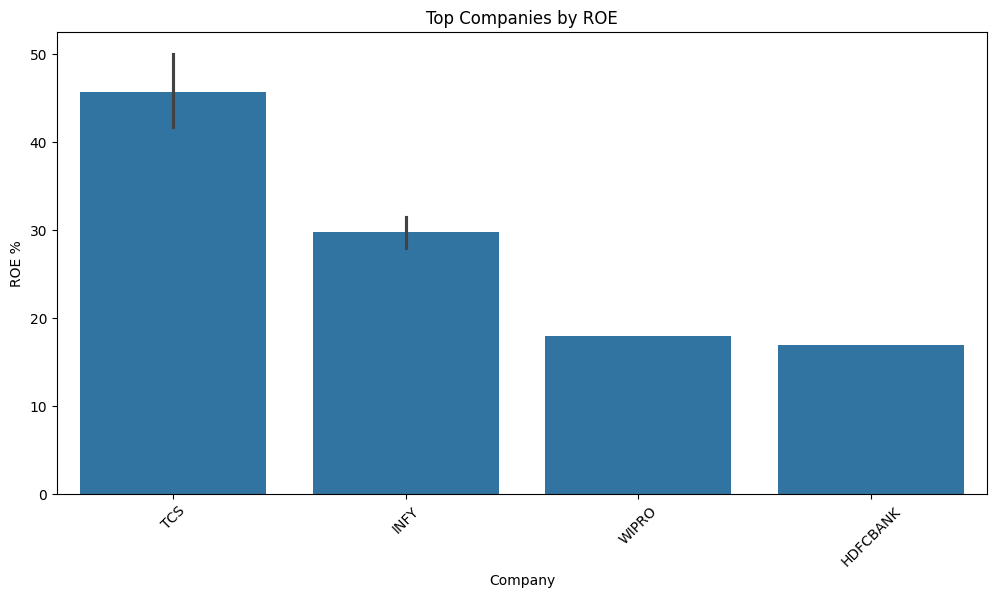

In [101]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_roe,
    x="company_id",
    y="roe_pct"
)

plt.title("Top Companies by ROE")
plt.xlabel("Company")
plt.ylabel("ROE %")

plt.xticks(rotation=45)

plt.show()

# Correlation Matrix

In [102]:
numeric_cols = [
    "sales_growth_pct",
    "profit_growth_pct",
    "stock_cagr_pct",
    "roe_pct"
]

corr = fact_analysis[numeric_cols].corr()

corr

,sales_growth_pct,profit_growth_pct,stock_cagr_pct,roe_pct
sales_growth_pct,1.000000,0.742530,-0.541350,-0.423883
profit_growth_pct,0.742530,1.000000,-0.268688,-0.190924
stock_cagr_pct,-0.541350,-0.268688,1.000000,0.124464
roe_pct,-0.423883,-0.190924,0.124464,1.000000


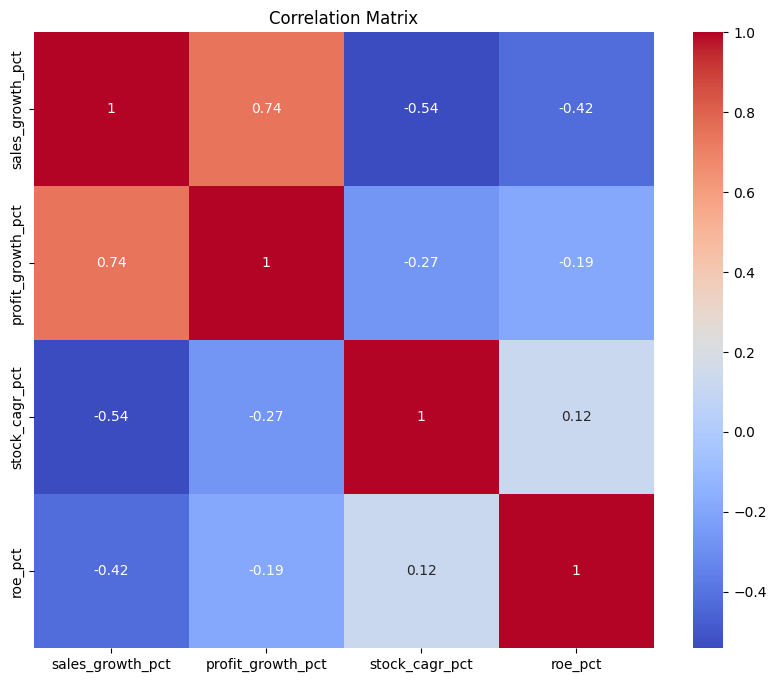

In [103]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Missing value Analysis

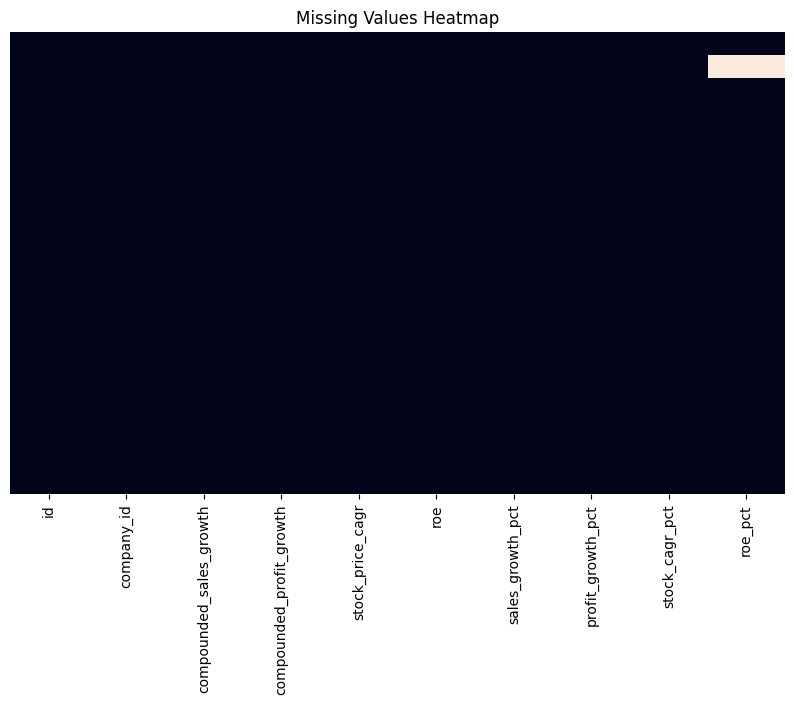

In [104]:
plt.figure(figsize=(10,6))

sns.heatmap(
    fact_analysis.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

# Top & Bottom companies by Metrics

In [105]:
top_sales_growth = fact_analysis.sort_values(
    by="sales_growth_pct",
    ascending=False
)

top_sales_growth[[
    "company_id",
    "sales_growth_pct"
]].head(10)

,company_id,sales_growth_pct
14,HDFCBANK,47.0
3,SBILIFE,43.0
13,HDFCBANK,30.0
1,SBILIFE,24.0
19,SBILIFE,23.0
11,HDFCBANK,22.0
0,HDFCBANK,21.0
2,SBILIFE,17.0
6,TCS,14.0
16,INFY,13.0


In [106]:
bottom_sales_growth = fact_analysis.sort_values(
    by="sales_growth_pct",
    ascending=True
)

bottom_sales_growth[[
    "company_id",
    "sales_growth_pct"
]].head(10)

,company_id,sales_growth_pct
12,WIPRO,-3.0
18,INFY,3.0
17,INFY,5.0
7,TCS,5.0
8,WIPRO,8.0
9,WIPRO,9.0
5,TCS,10.0
4,TCS,11.0
15,INFY,12.0
16,INFY,13.0


In [107]:
fig = px.scatter(
    fact_analysis,
    x="sales_growth_pct",
    y="profit_growth_pct",
    color="company_id",
    hover_data=["roe_pct"]
)

fig.show()

In [108]:
fact_analysis.to_csv(
    "../exports/cleaned_fact_analysis.csv",
    index=False
)